In [23]:
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import TwoSlopeNorm

# ── Project root ─────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'MedGrid'))

import med_grid_env  # registers MedGrid-v0 and MedGrid-discrete-v0
import gymnasium as gym

# ── Run to analyse ───────────────────────────────────────────────────────────
RUN_NAME = 'medgrid_15_bins'
RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', RUN_NAME)

# ── Discrete action space parameters ─────────────────────────────────────────
N_BINS      = 15                   # bins per axis
ACTION_SIZE = N_BINS * N_BINS      # 225 total discrete actions
bins        = np.linspace(0.0, 10.0, N_BINS, dtype=np.float32)
ACTION_MAP  = np.array([(x, y) for x in bins for y in bins], dtype=np.float32)
# ACTION_MAP[i] = (x_target, y_target) for discrete action i

print(f'N_BINS={N_BINS}  →  ACTION_SIZE={ACTION_SIZE}')
print(f'ACTION_MAP shape: {ACTION_MAP.shape}  (exhaustive — no sampling needed)')

N_BINS=15  →  ACTION_SIZE=225
ACTION_MAP shape: (225, 2)  (exhaustive — no sampling needed)


## 1. Ground truth regions

MedGrid is a **10×10** continuous gridworld with:
* **Red (Death):** quarter-circles of radius 3 at bottom-left $(0,0)$ and top-right $(10,10)$.
* **Yellow (Trap):** annular bands $3 < d \le 5$ around each death zone corner.
* **Blue (Recovery):** a rotated ellipse centred at $(5,5)$, semi-major $a=3$, semi-minor $b=1.5$, tilted $-45°$.
* **White (Neutral):** everything else.
* **Start:** bottom-right corner $(10, 0)$.

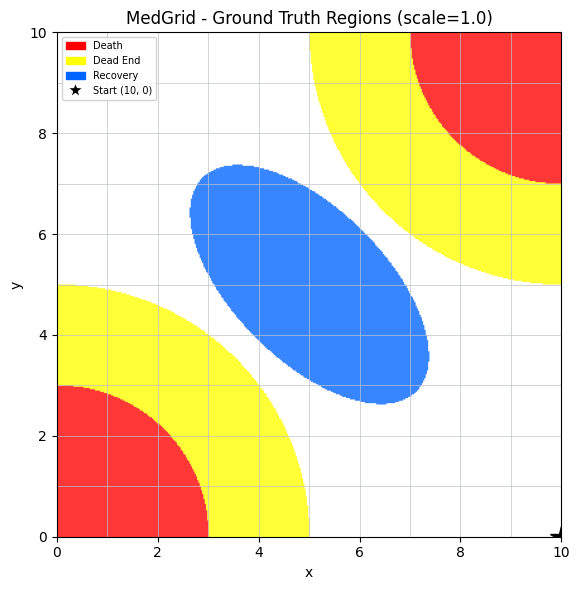

In [24]:
SCALE      = 1.0   # set < 1 to shrink danger/recovery zones proportionally
SIZE       = 10.0
DEATH_R    = 3.0 * SCALE
TRAP_R     = 5.0 * SCALE
ELLIPSE_A  = 3.0 * SCALE
ELLIPSE_B  = 1.5 * SCALE
RESOLUTION = 800

# Backward-compatible aliases used by later cells.
DEATH_COLOR_HEX    = '#ff0000'
DEAD_END_COLOR_HEX = '#ffff00'
RECOVERY_COLOR_HEX = '#0064ff'
NEUTRAL_COLOR_HEX  = '#ffffff'
START_COLOR_HEX    = '#000000'


def hex_to_rgba(hex_color, alpha=255):
    """Convert '#RRGGBB' color to an RGBA uint8 array."""
    value = hex_color.lstrip('#')
    if len(value) != 6:
        raise ValueError(f'Invalid hex color: {hex_color}')
    return np.array([
        int(value[0:2], 16),
        int(value[2:4], 16),
        int(value[4:6], 16),
        int(alpha),
    ], dtype=np.uint8)


def classify_point(x, y):
    """Return region label for a single (x, y) point."""
    d_bl = np.sqrt(x**2 + y**2)
    d_tr = np.sqrt((x - 10)**2 + (y - 10)**2)

    if d_bl <= DEATH_R or d_tr <= DEATH_R:
        return 'death'
    if d_bl <= TRAP_R or d_tr <= TRAP_R:
        return 'trap'
    dx, dy = x - 5.0, y - 5.0
    if ((dx - dy)**2 / (2 * ELLIPSE_A**2) + (dx + dy)**2 / (2 * ELLIPSE_B**2)) <= 1.0:
        return 'recovery'
    return 'neutral'


def build_region_image(resolution=RESOLUTION):
    """Rasterise the region map into an RGBA image for imshow."""
    colors = {
        'death':    hex_to_rgba(DEATH_COLOR_HEX, alpha=200),
        'trap':     hex_to_rgba(DEAD_END_COLOR_HEX, alpha=200),
        'recovery': hex_to_rgba(RECOVERY_COLOR_HEX, alpha=200),
        'neutral':  hex_to_rgba(NEUTRAL_COLOR_HEX, alpha=255),
    }
    xs = np.linspace(0, SIZE, resolution)
    ys = np.linspace(0, SIZE, resolution)
    img = np.zeros((resolution, resolution, 4), dtype=np.uint8)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            img[j, i] = colors[classify_point(x, y)]
    return img


def plot_ground_truth(ax=None, resolution=RESOLUTION):
    """Draw the MedGrid region layout. Returns (fig, ax)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    img = build_region_image(resolution)
    ax.imshow(img, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal')

    # 1-unit grid lines
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.5, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.5, zorder=2)

    # Start position
    ax.plot(10, 0, marker='*', color=START_COLOR_HEX, markersize=16,
            label='Start (10, 0)', zorder=5)

    # Legend patches
    legend_patches = [
        mpatches.Patch(color=DEATH_COLOR_HEX, label='Death'),
        mpatches.Patch(color=DEAD_END_COLOR_HEX, label='Dead End'),
        mpatches.Patch(color=RECOVERY_COLOR_HEX, label='Recovery'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor=START_COLOR_HEX,
                   markersize=12, label='Start (10, 0)'),
    ]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=7, framealpha=0.85)

    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, SIZE)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'MedGrid - Ground Truth Regions (scale={SCALE})')
    return fig, ax


fig, ax = plot_ground_truth(resolution=400)
plt.tight_layout()
plt.show()

## 4. Sanity check — environment API

In [25]:
env = gym.make('MedGrid-v0')
obs, _ = env.reset()
print(f'Start state: {obs}  (expected [10. 0.])')

# Step directly into recovery zone (centre 5,5)
obs, r, term, trunc, _ = env.step(np.array([5.0, 5.0]))
print(f'Step to (5,5): obs={obs}, reward={r}, terminated={term}  (expect +1, True)')

# Reset and step into death zone BL
obs, _ = env.reset()
obs, r, term, trunc, _ = env.step(np.array([1.0, 1.0]))
print(f'Step to (1,1): obs={obs}, reward={r}, terminated={term}  (expect -1, True)')

# Reset and step into Trap1, then verify forced transition
obs, _ = env.reset()
obs, r, term, trunc, _ = env.step(np.array([4.0, 0.5]))   # inside Trap1 band
print(f'Step to BL trap (4.0,0.5): obs={obs}, reward={r}, terminated={term}  (expect 0, False)')
obs2, r2, term2, trunc2, _ = env.step(np.array([8.0, 8.0]))  # action ignored
print(f'Forced from Trap1:          obs={obs2}, reward={r2}, terminated={term2}  (expect [1.5 1.5], -1, True)')

env.close()

Start state: [10.  0.]  (expected [10. 0.])
Step to (5,5): obs=[5. 5.], reward=1.0, terminated=True  (expect +1, True)
Step to (1,1): obs=[1. 1.], reward=-1.0, terminated=True  (expect -1, True)
Step to BL trap (4.0,0.5): obs=[4.  0.5], reward=0.0, terminated=False  (expect 0, False)
Forced from Trap1:          obs=[1.5 1.5], reward=-1.0, terminated=True  (expect [1.5 1.5], -1, True)


## 5. Discrete wrapper sanity check

In [26]:
env_d = gym.make('MedGrid-discrete-v0', n_bins=N_BINS)
obs, _ = env_d.reset()
print(f'Discrete action space size (n_bins={N_BINS}): {env_d.action_space.n}  (expect {N_BINS**2})')
print(f'Observation space: {env_d.observation_space}')
# Verify action map matches the wrapper's internal map
wrapper_map = env_d.unwrapped._action_map if hasattr(env_d.unwrapped, '_action_map') else env_d._action_map
print(f'ACTION_MAP matches wrapper: {np.allclose(ACTION_MAP, wrapper_map)}')
env_d.close()

Discrete action space size (n_bins=15): 225  (expect 225)
Observation space: Box(0.0, 10.0, (2,), float32)


AttributeError: 'OrderEnforcing' object has no attribute '_action_map'

## 6. Load trained agents

Agents trained with:
```bash
cd toy_domain
../.venv/bin/python run.py -env MedGrid -action_mode discrete -n_bins 15 \
    -agent iqn -ded -frames 500000 -info medgrid_15_bins
```

In [27]:
import io

class CpuUnpickler(pickle.Unpickler):
    """Unpickler that maps CUDA-backed torch storages onto CPU."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(
                io.BytesIO(b), map_location=torch.device('cpu'), weights_only=False
            )
        return super().find_class(module, name)


def load_pickle_cpu(path):
    with open(path, 'rb') as f:
        return CpuUnpickler(f).load()


agent, qd, qr = None, None, None
try:
    agent = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_agent.pkl'))
    print('Loaded main agent')
    qd = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qd.pkl'))
    qr = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qr.pkl'))
    print('Loaded Qd and Qr networks')
    # Confirm action_size matches
    net = qd.qnetwork_local
    print(f'Network action_size = {net.action_size}  (expect {ACTION_SIZE})')
except FileNotFoundError as e:
    print(f'Agents not found ({e}) — train first.')
except RuntimeError as e:
    print(f'Failed to load agents: {e}')

Loaded main agent
Loaded Qd and Qr networks
Network action_size = 225  (expect 225)


## 7. CVaR Q-value heatmap over all discrete actions at a fixed state

The discrete IQN network maps **state → Q(s, a) for all actions** in a single forward pass.
With 15 bins we get all **225 actions exhaustively** — no random sampling required.

For a fixed state, the forward pass returns `(1, num_tau, 225)` quantiles.
CVaR is computed over the `num_tau` dimension for each action, then plotted at
each action's `(x_target, y_target)` coordinate from `ACTION_MAP`.

CVaR alpha=0.2  →  using lowest 6/32 quantiles
Evaluating ALL 225 discrete actions (single forward pass per network)
Computing Qd CVaR (single forward pass)...
  range: [-1.048, 0.031]
Computing Qr CVaR (single forward pass)...
  range: [-0.015, 1.011]


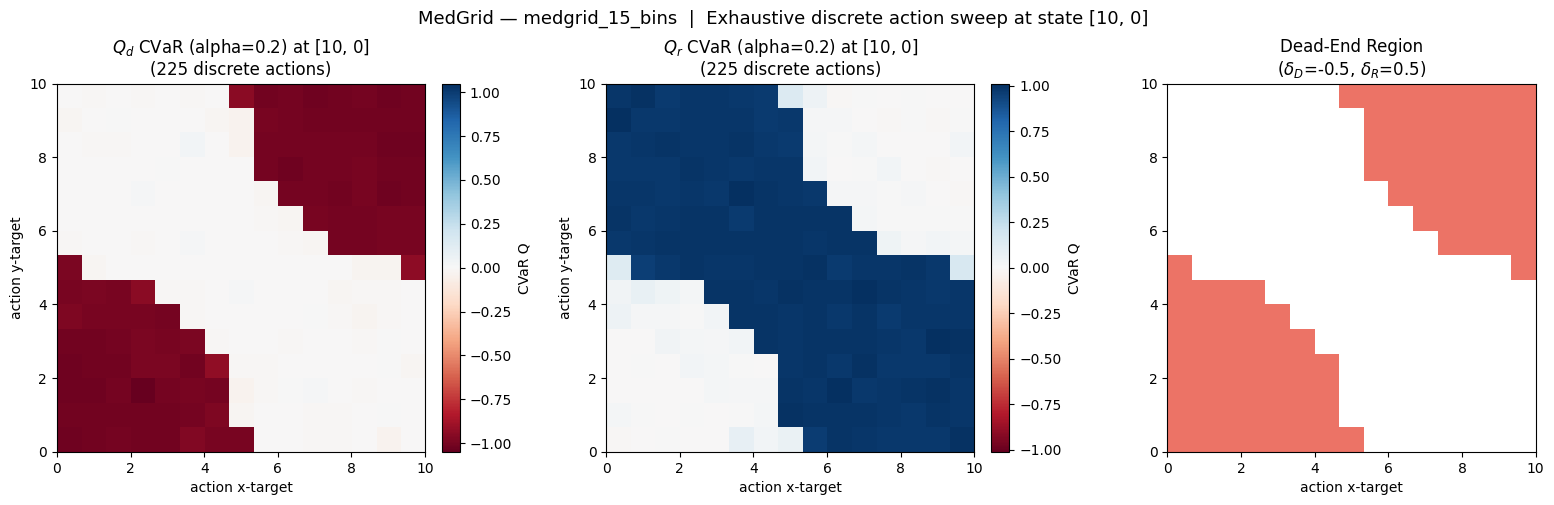

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_15_bins/medgrid_ded_action_heatmap.png


In [28]:
N_TAU       = 32
alpha       = 0.2
DEVICE      = 'cpu'
FIXED_STATE = [10, 0]

N_KEEP = max(1, int(alpha * N_TAU))
print(f'CVaR alpha={alpha}  →  using lowest {N_KEEP}/{N_TAU} quantiles')
print(f'Evaluating ALL {ACTION_SIZE} discrete actions (single forward pass per network)')


def _prepare_iqn_for_device(ded_agent, device):
    network = ded_agent.qnetwork_local
    network.to(device)
    network.device = device
    if hasattr(network, 'pis'):
        network.pis = network.pis.to(device)
    return network


def compute_action_cvar_discrete(ded_agent, state=FIXED_STATE, n_tau=N_TAU,
                                  eta=alpha, device=DEVICE):
    """Return CVaR for every discrete action at a single state.

    The discrete IQN forward pass takes (batch, state_dim) and returns
    (batch, num_tau, action_size).  We use batch_size=1 to get all
    ACTION_SIZE Q-distributions in one shot.

    Returns
    -------
    cvar : (ACTION_SIZE,) float array — lower CVaR per action
    """
    n_keep  = max(1, int(eta * n_tau))
    network = _prepare_iqn_for_device(ded_agent, device)
    network.eval()

    s_t = torch.tensor([state], dtype=torch.float32).to(device)  # (1, 2)

    with torch.no_grad():
        quantiles, _ = network.forward(s_t, num_tau=n_tau)   # (1, n_tau, action_size)

    q = quantiles[0].cpu().numpy()                            # (n_tau, action_size)
    q_sorted = np.sort(q, axis=0)                             # sort over tau
    cvar = q_sorted[:n_keep, :].mean(axis=0)                  # (action_size,)
    return cvar


def plot_action_heatmap(cvar, action_map, title, ax=None):
    """Scatter plot of CVaR values at each action's (x, y) target coordinate.
    With 15 bins the 225 points form a regular grid — we also overlay it as
    an image for clarity.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    vmax = max(np.abs(cvar).max(), 1e-6)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    # Reshape to grid for imshow background
    grid = cvar.reshape(N_BINS, N_BINS)          # (x_idx, y_idx)
    im = ax.imshow(grid.T, origin='lower',        # transpose: rows=y, cols=x
                   extent=[0, 10, 0, 10], aspect='equal',
                   cmap='RdBu', norm=norm, interpolation='nearest')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='CVaR Q')

    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_xlabel('action x-target'); ax.set_ylabel('action y-target')
    ax.set_title(title)
    return fig, ax


if qd is not None and qr is not None:
    print('Computing Qd CVaR (single forward pass)...')
    cvar_d = compute_action_cvar_discrete(qd)
    print(f'  range: [{cvar_d.min():.3f}, {cvar_d.max():.3f}]')

    print('Computing Qr CVaR (single forward pass)...')
    cvar_r = compute_action_cvar_discrete(qr)
    print(f'  range: [{cvar_r.min():.3f}, {cvar_r.max():.3f}]')

    delta_d = -0.5
    delta_r = 0.5
    dead_end_grid = (
        cvar_d.reshape(N_BINS, N_BINS) <= delta_d
    ) & (
        cvar_r.reshape(N_BINS, N_BINS) <= delta_r
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    dead_rgba = np.zeros((N_BINS, N_BINS, 4), dtype=np.uint8)
    dead_rgba[ dead_end_grid] = [231,  76,  60, 200]
    dead_rgba[~dead_end_grid] = [255, 255, 255, 220]
    axes[2].imshow(np.transpose(dead_rgba, (1, 0, 2)), origin='lower',
                   extent=[0, 10, 0, 10], interpolation='nearest', aspect='equal')
    axes[2].set_xlim(0, 10); axes[0].set_ylim(0, 10)
    axes[2].set_xlabel('action x-target'); axes[0].set_ylabel('action y-target')
    axes[2].set_title(
        f'Dead-End Region\n($\\delta_D$={delta_d}, $\\delta_R$={delta_r})')

    plot_action_heatmap(cvar_d, ACTION_MAP,
                        title=f'$Q_d$ CVaR (alpha={alpha}) at {FIXED_STATE}\n({ACTION_SIZE} discrete actions)', ax=axes[0])
    plot_action_heatmap(cvar_r, ACTION_MAP,
                        title=f'$Q_r$ CVaR (alpha={alpha}) at {FIXED_STATE}\n({ACTION_SIZE} discrete actions)', ax=axes[1])
    fig.suptitle(f'MedGrid — {RUN_NAME}  |  Exhaustive discrete action sweep at state {FIXED_STATE}', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(RUN_DIR, 'medgrid_ded_action_heatmap.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — no trained agents loaded.')

## 8. Fixed-State Action-Space Classification

Evaluate DistDeD at the fixed start state using the full discrete action grid.

Each action bin is treated as a candidate target position.

**Prediction rule:** an action bin is predicted as a dead-end when both
$Q_d$ and $Q_r$ lower-CVaR values cross their thresholds:

$\mathrm{CVaR}(Q_d) \leq \delta_D$ and $\mathrm{CVaR}(Q_r) \leq \delta_R$

**Ground truth:** `classify_point(action_x, action_y)` returning `'death'` or `'trap'`.

Sampling 100000 continuous actions in [0, 10.0]^2 at state [10, 0] ...
  δD = -0.5,  δR = 0.5,  α = 0.2,  seed = 7


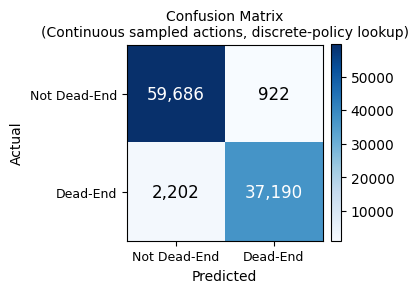


TP=37190  TN=59686  FP=922  FN=2202


In [29]:
DELTA_D = -0.5
DELTA_R =  0.5
N_CONT_ACTION_SAMPLES = 100000
SAMPLE_SEED = 7


def compute_action_cvar_grid_discrete(ded_agent, state=FIXED_STATE,
                                      n_tau=N_TAU, eta=alpha, device=DEVICE):
    """Return lower-CVaR values over the full discrete action grid at one state."""
    network = _prepare_iqn_for_device(ded_agent, device)
    network.eval()

    state_tensor = torch.tensor([state], dtype=torch.float32, device=device)
    n_keep = max(1, int(eta * n_tau))

    with torch.no_grad():
        quantiles, _ = network.forward(state_tensor, num_tau=n_tau)  # (1, n_tau, action_size)

    q = quantiles[0].cpu().numpy()               # (n_tau, action_size)
    q_sorted = np.sort(q, axis=0)                # sort over tau
    cvar = q_sorted[:n_keep, :].mean(axis=0)     # (action_size,)

    action_bins = np.linspace(0.0, SIZE, N_BINS, dtype=np.float32)
    return cvar.reshape(N_BINS, N_BINS), action_bins


def nearest_discrete_indices(actions, action_bins):
    """Map continuous actions to nearest discrete (x_bin, y_bin) indices."""
    ix = np.abs(actions[:, 0][:, None] - action_bins[None, :]).argmin(axis=1)
    iy = np.abs(actions[:, 1][:, None] - action_bins[None, :]).argmin(axis=1)
    return ix, iy


def plot_confusion_matrix(cm, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3.5))
    else:
        fig = ax.figure

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    labels = ['Not Dead-End', 'Dead-End']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title('Confusion Matrix\n(Continuous sampled actions, discrete-policy lookup)', fontsize=10)

    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > thresh else 'black')
    return fig, ax


if qd is not None and qr is not None:
    print(f'Sampling {N_CONT_ACTION_SAMPLES} continuous actions in [0, {SIZE}]^2 at state {FIXED_STATE} ...')
    print(f'  δD = {DELTA_D},  δR = {DELTA_R},  α = {alpha},  seed = {SAMPLE_SEED}')

    # Model outputs exist only on the discrete action grid for this policy.
    cvar_d_action_grid, action_bins = compute_action_cvar_grid_discrete(qd)
    cvar_r_action_grid, _ = compute_action_cvar_grid_discrete(qr)

    # Keep the discrete masks for downstream plots and Boundary IoU.
    gt_action_grid = np.array(
        [[classify_point(x, y) in ('death', 'trap') for y in action_bins] for x in action_bins],
        dtype=bool,
    )
    pred_action_grid = (cvar_d_action_grid <= DELTA_D) & (cvar_r_action_grid <= DELTA_R)

    rng = np.random.default_rng(SAMPLE_SEED)
    sampled_actions = rng.uniform(0.0, SIZE, size=(N_CONT_ACTION_SAMPLES, 2)).astype(np.float32)

    # Compare each continuous action against nearest discrete action-bin prediction.
    ix, iy = nearest_discrete_indices(sampled_actions, action_bins)
    pred_sample = pred_action_grid[ix, iy]

    gt_sample = np.array(
        [classify_point(a[0], a[1]) in ('death', 'trap') for a in sampled_actions],
        dtype=bool,
    )

    TP = int(( gt_sample &  pred_sample).sum())
    TN = int((~gt_sample & ~pred_sample).sum())
    FP = int((~gt_sample &  pred_sample).sum())
    FN = int(( gt_sample & ~pred_sample).sum())
    cm_action = np.array([[TN, FP], [FN, TP]])

    fig, ax = plt.subplots(figsize=(4, 3.5))
    plot_confusion_matrix(cm_action, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'confusion_matrix_discrete_sampled_cont_actions.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTP={TP}  TN={TN}  FP={FP}  FN={FN}')
else:
    print('Skipped — no trained agents loaded.')

## 9. Classification Metrics — Sampled Actions

Precision, recall, and F1 are computed from the sampled continuous-action evaluation above.
Boundary IoU is computed on the discrete action-grid masks used by the policy lookup.

Classification Metrics at state [10, 0]
  Precision / Recall / F1 use the sampled continuous actions.
  Boundary IoU uses 200×200 rasterisation (nearest-bin lookup).
  Precision    : 0.9758
  Recall       : 0.9441
  F1 Score     : 0.9597
  Boundary IoU : 0.0356


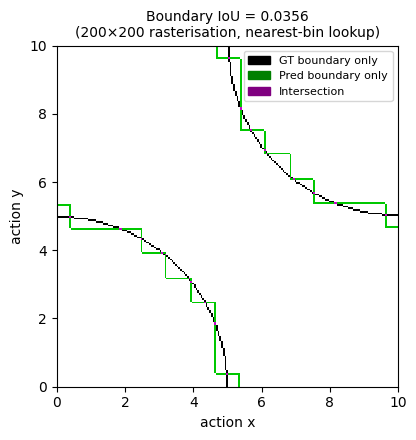

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_15_bins/metrics_boundary_iou_discrete.png


In [30]:
def boundary_mask(binary_grid):
    """Return boundary pixels using 4-neighbour connectivity on a boolean grid."""
    g = binary_grid.astype(np.int8)
    shifted = (
        np.pad(g, ((1, 0), (0, 0)), mode='edge')[:-1, :]
        + np.pad(g, ((0, 1), (0, 0)), mode='edge')[1:, :]
        + np.pad(g, ((0, 0), (1, 0)), mode='edge')[:, :-1]
        + np.pad(g, ((0, 0), (0, 1)), mode='edge')[:, 1:]
    )
    return binary_grid & (shifted < 4)


def boundary_iou(gt_grid, pred_grid):
    gt_boundary = boundary_mask(gt_grid)
    pred_boundary = boundary_mask(pred_grid)
    intersection = (gt_boundary & pred_boundary).sum()
    union = (gt_boundary | pred_boundary).sum()
    return float(intersection) / float(union) if union > 0 else float('nan')


precision = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
recall = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else float('nan')
)

# ── Boundary IoU on a high-resolution rasterisation ─────────────────────────
# The coarse action grid (N_BINS × N_BINS = 15×15) has limited boundary pixels.
# Rasterise both GT and predicted regions at BIOU_RES × BIOU_RES using
# nearest-bin lookup for the prediction, giving a more accurate IoU.
BIOU_RES = 200
xs_biou = np.linspace(0, SIZE, BIOU_RES, dtype=np.float32)
ys_biou = np.linspace(0, SIZE, BIOU_RES, dtype=np.float32)

# GT: gt_hires[i, j] = classify(xs[i], ys[j])
gt_hires = np.array(
    [[classify_point(x, y) in ('death', 'trap') for y in ys_biou]
     for x in xs_biou],
    dtype=bool,
)

# Pred: nearest-bin lookup; ix_h[i] = closest action_bin index for xs_biou[i]
ix_h = np.abs(xs_biou[:, None] - action_bins[None, :]).argmin(axis=1)
iy_h = np.abs(ys_biou[:, None] - action_bins[None, :]).argmin(axis=1)
pred_hires = pred_action_grid[np.ix_(ix_h, iy_h)]  # (BIOU_RES, BIOU_RES)

biou = boundary_iou(gt_hires, pred_hires)

print('=' * 60)
print(f'Classification Metrics at state {FIXED_STATE}')
print('  Precision / Recall / F1 use the sampled continuous actions.')
print(f'  Boundary IoU uses {BIOU_RES}×{BIOU_RES} rasterisation (nearest-bin lookup).')
print(f'  Precision    : {precision:.4f}')
print(f'  Recall       : {recall:.4f}')
print(f'  F1 Score     : {f1:.4f}')
print(f'  Boundary IoU : {biou:.4f}')
print('=' * 60)

# ── Boundary visualisation ────────────────────────────────────────────────────
gt_b   = boundary_mask(gt_hires)
pred_b = boundary_mask(pred_hires)
overlap = gt_b & pred_b

# gt_hires[i, j] → (xs[i], ys[j]); need np.transpose for imshow (origin='lower')
bnd_img = np.zeros((*gt_b.shape, 3), dtype=np.uint8) + 255
bnd_img[gt_b   & ~overlap] = [0,   0,   0]
bnd_img[pred_b & ~overlap] = [0,   200, 0]
bnd_img[overlap]            = [200, 0,   200]

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.imshow(
    np.transpose(bnd_img, (1, 0, 2)),
    origin='lower',
    extent=[0, SIZE, 0, SIZE],
    interpolation='nearest',
    aspect='equal',
)
legend_patches = [
    mpatches.Patch(color='black',  label='GT boundary only'),
    mpatches.Patch(color='green',  label='Pred boundary only'),
    mpatches.Patch(color='purple', label='Intersection'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='upper right')
ax.set_xlabel('action x')
ax.set_ylabel('action y')
ax.set_title(f'Boundary IoU = {biou:.4f}\n({BIOU_RES}×{BIOU_RES} rasterisation, nearest-bin lookup)', fontsize=10)
plt.tight_layout()
out_path = os.path.join(RUN_DIR, 'metrics_boundary_iou_discrete.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', out_path)
